# **TasK#01**

---



In [20]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import mnist


In [21]:
# Step 1: Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()  # Load the dataset

# Normalize the pixel values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0  # Scale training data
x_test = x_test.astype('float32') / 255.0  # Scale test data

# One-hot encode the labels (0-9) for categorical classification
y_train = to_categorical(y_train, 10)  # Encode training labels
y_test = to_categorical(y_test, 10)  # Encode test labels

# ***Part#01:***

In [22]:

model_v1 = Sequential([
    Flatten(input_shape=(28, 28)),  # Flatten 28x28 images to a 1D vector of 784 features
    Dense(128, activation='sigmoid'),  # Hidden layer with 128 neurons and ReLU activation  <----------------------------used sigmoid to analyse behaviour
    Dense(128, activation='relu'),  # Hidden layer with 64 neurons and ReLU activation      <----------------------------Changed the no of neurons 64-->128
    Dense(10, activation='softmax')  # Output layer with 10 neurons and softmax activation
])

# Print the model summary to understand the architecture
model_v1.summary()


# Step 3: Compile the model
model_v1.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
# Step 4: Train the model
history = model_v1.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)
# Step 5: Evaluate the model
test_loss, test_accuracy = model_v1.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")  # Print the test accuracy


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8924 - loss: 0.3834 - val_accuracy: 0.9369 - val_loss: 0.2064
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9468 - loss: 0.1731 - val_accuracy: 0.9592 - val_loss: 0.1408
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9635 - loss: 0.1202 - val_accuracy: 0.9643 - val_loss: 0.1161
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9715 - loss: 0.0914 - val_accuracy: 0.9691 - val_loss: 0.1032
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9787 - loss: 0.0701 - val_accuracy: 0.9707 - val_loss: 0.0942
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9828 - loss: 0.0555 - val_accuracy: 0.9693 - val_loss: 0.0975
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9855 - loss: 0.0442 - val_accuracy: 0.9732 - val_loss: 0.0894
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9884 - loss: 0.0354 -

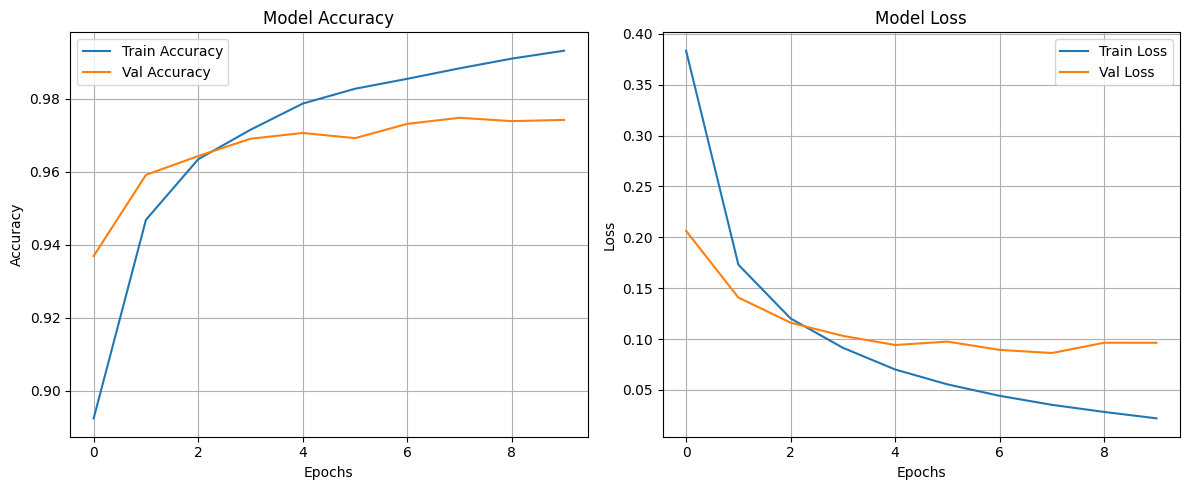

In [23]:

# Step 6: Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 5))  # Create a figure with a specific size

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)  # Create a subplot for accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')  # Plot training accuracy
plt.plot(history.history['val_accuracy'], label='Val Accuracy')  # Plot validation accuracy
plt.title('Model Accuracy')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Accuracy')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

# Plot training & validation loss values
plt.subplot(1, 2, 2)  # Create a subplot for loss
plt.plot(history.history['loss'], label='Train Loss')  # Plot training loss
plt.plot(history.history['val_loss'], label='Val Loss')  # Plot validation loss
plt.title('Model Loss')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Loss')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

plt.tight_layout()  # Adjust subplots to fit into figure area
plt.show()  # Display the plots

# ***Part#02:***

In [15]:

model_v2 = Sequential([
    Flatten(input_shape=(28, 28)),  # Flatten 28x28 images to a 1D vector of 784 features
    Dense(128, activation='sigmoid'),  # Hidden layer with 128 neurons and ReLU activation
    Dense(64, activation='relu'),  # Hidden layer with 64 neurons and ReLU activation
    Dense(32, activation='relu'),  # Hidden layer with 64 neurons and ReLU activation   ---------------------------> added another layer
    Dense(10, activation='softmax')  # Output layer with 10 neurons and softmax activation
])

# Print the model summary to understand the architecture
model_v2.summary()


# Step 3: Compile the model
model_v2.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
# Step 4: Train the model
history = model_v2.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)
# Step 5: Evaluate the model
test_loss, test_accuracy = model_v2.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")  # Print the test accuracy



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8824 - loss: 0.4006 - val_accuracy: 0.9300 - val_loss: 0.2343
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9472 - loss: 0.1768 - val_accuracy: 0.9583 - val_loss: 0.1449
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9626 - loss: 0.1213 - val_accuracy: 0.9634 - val_loss: 0.1232
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9718 - loss: 0.0902 - val_accuracy: 0.9658 - val_loss: 0.1117
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9774 - loss: 0.0716 - val_accuracy: 0.9696 - val_loss: 0.1007
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9815 - loss: 0.0581 - val_accuracy: 0.9679 - val_loss: 0.1012
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9856 - loss: 0.0466 - val_accuracy: 0.9743 - val_loss: 0.0862
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9881 - loss: 0.

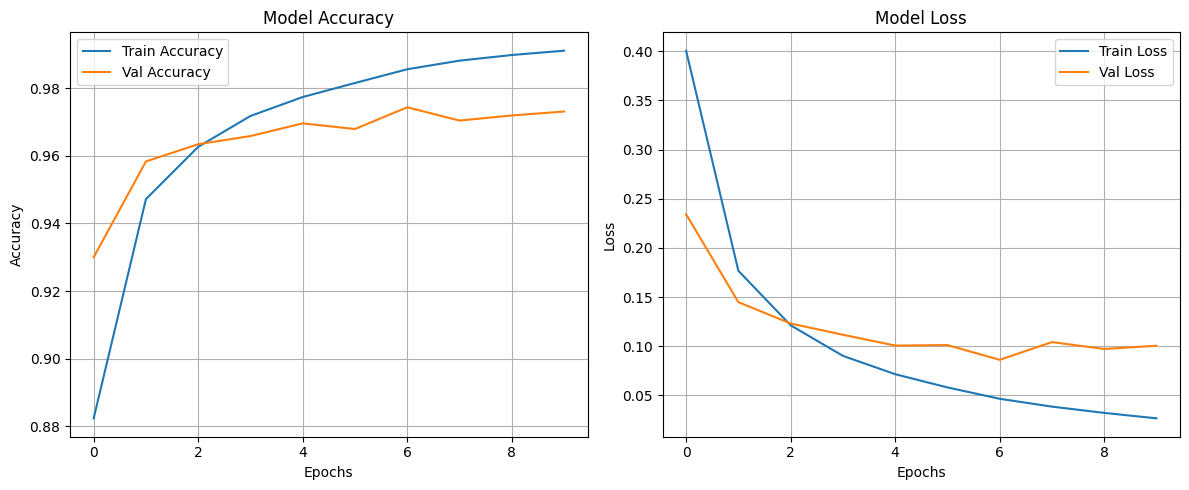

In [16]:
# Step 6: Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 5))  # Create a figure with a specific size

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)  # Create a subplot for accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')  # Plot training accuracy
plt.plot(history.history['val_accuracy'], label='Val Accuracy')  # Plot validation accuracy
plt.title('Model Accuracy')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Accuracy')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

# Plot training & validation loss values
plt.subplot(1, 2, 2)  # Create a subplot for loss
plt.plot(history.history['loss'], label='Train Loss')  # Plot training loss
plt.plot(history.history['val_loss'], label='Val Loss')  # Plot validation loss
plt.title('Model Loss')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Loss')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

plt.tight_layout()  # Adjust subplots to fit into figure area
plt.show()  # Display the plots


# ***Part#03***

In [17]:

model_v3 = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),   #---------------------------> kept all activation as Relu and make the layes go from 256 to 32
    Dense(10, activation='softmax')
])

# Print the model summary to understand the architecture
model_v3.summary()


# Step 3: Compile the model
model_v3.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
# Step 4: Train the model
history = model_v3.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)
# Step 5: Evaluate the model
test_loss, test_accuracy = model_v3.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")  # Print the test accuracy





Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,522 (955.16 KB)

 Trainable params: 244,522 (955.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9226 - loss: 0.2555 - val_accuracy: 0.9599 - val_loss: 0.1318
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9682 - loss: 0.1057 - val_accuracy: 0.9687 - val_loss: 0.1038
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9766 - loss: 0.0756 - val_accuracy: 0.9722 - val_loss: 0.0888
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9827 - loss: 0.0562 - val_accuracy: 0.9735 - val_loss: 0.0922
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9861 - loss: 0.0455 - val_accuracy: 0.9727 - val_loss: 0.0942
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9878 - loss: 0.0390 - val_accuracy: 0.9747 - val_loss: 0.0942
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9893 - loss: 0.0322 - val_accuracy: 0.9697 - val_loss: 0.1054
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9907 - loss: 0

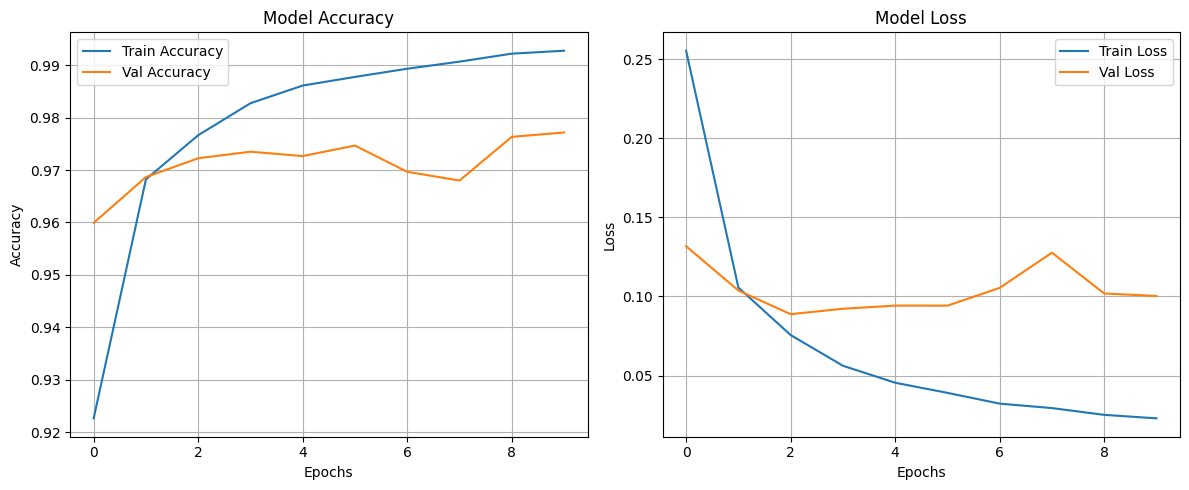

In [18]:

# Step 6: Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 5))  # Create a figure with a specific size

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)  # Create a subplot for accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')  # Plot training accuracy
plt.plot(history.history['val_accuracy'], label='Val Accuracy')  # Plot validation accuracy
plt.title('Model Accuracy')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Accuracy')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

# Plot training & validation loss values
plt.subplot(1, 2, 2)  # Create a subplot for loss
plt.plot(history.history['loss'], label='Train Loss')  # Plot training loss
plt.plot(history.history['val_loss'], label='Val Loss')  # Plot validation loss
plt.title('Model Loss')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Loss')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

plt.tight_layout()  # Adjust subplots to fit into figure area
plt.show()  # Display the plots

# ***Part#04***

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 728,288 (2.78 MB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 485,526 (1.85 MB)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9183 - loss: 0.2964 - val_accuracy: 0.9612 - val_loss: 0.1346
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9695 - loss: 0.1016 - val_accuracy: 0.9703 - val_loss: 0.0961
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9797 - loss: 0.0664 - val_accuracy: 0.9677 - val_loss: 0.1063
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9855 - loss: 0.0480 - val_accuracy: 0.9701 - val_loss: 0.0985
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9879 - loss: 0.0389 - val_accuracy: 0.9743 - val_loss: 0.0918
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9911 - loss: 0.0295 - val_accuracy: 0.9759 - val_loss: 0.0895
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9915 - loss: 0.0265 - val_accuracy: 0.9780 - val_loss: 0.0836
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9931 - loss: 0

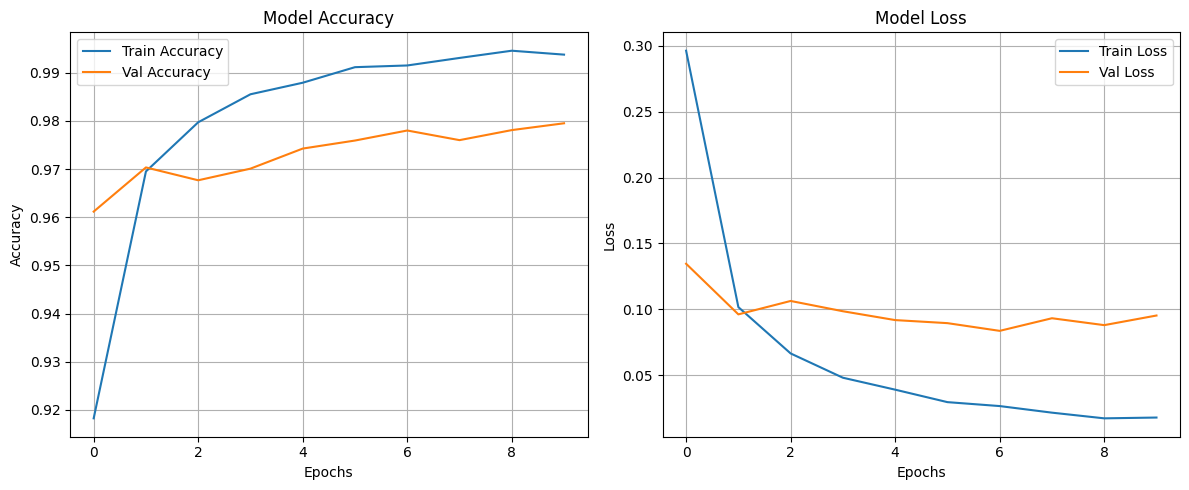

In [19]:

model_v4 = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='selu'),    #-----------------------------> uinsg Selu in the 4th layer
    Dense(10, activation='softmax')
])

# Print the model asummary to understand the architecture
model_v4.summary()


# Step 3: Compile the model
model_v4.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
# Step 4: Train the model
history = model_v4.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)
# Step 5: Evaluate the model
test_loss, test_accuracy = model_v4.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")  # Print the test accuracy



# Step 6: Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 5))  # Create a figure with a specific size

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)  # Create a subplot for accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')  # Plot training accuracy
plt.plot(history.history['val_accuracy'], label='Val Accuracy')  # Plot validation accuracy
plt.title('Model Accuracy')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Accuracy')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

# Plot training & validation loss values
plt.subplot(1, 2, 2)  # Create a subplot for loss
plt.plot(history.history['loss'], label='Train Loss')  # Plot training loss
plt.plot(history.history['val_loss'], label='Val Loss')  # Plot validation loss
plt.title('Model Loss')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Loss')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

plt.tight_layout()  # Adjust subplots to fit into figure area
plt.show()  # Display the plots

All four architectures converge to a similar validation accuracy range of approximately 97ish percent, regardless of their depth, width, or choice of activation function. This performance is close to the typical accuracy ceiling achieved by conventional fully connected (dense) networks on the MNIST dataset.

All models exhibit some degree of overfitting, as indicated by the continued decrease in training loss after the validation loss has stopped improving, typically around epochs 4–6.

Changing the activation functions and number of hidden layers resulted in only marginal differences in performance. This suggests that, within the configurations tested, the overall architecture of a fully connected MLP is a more significant limiting factor than the specific hyperparameter choices. Further improvements would therefore likely require a different model architecture, such as a Convolutional Neural Network (CNN), rather than simply increasing the depth or modifying the activation functions of the MLP